<a href="https://colab.research.google.com/github/TienNguyen0712/ai-engineer-journey/blob/main/chapter1_pytorch_workflow_fundamentals/chapter1_pytorch_workflow_fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Luồng chạy của Pytorch Fundamentals**

Thông thường các công việc của học máy và học sâu chính là việc lấy các dữ liệu trong quá khứ, xây dựng thuật toán để khảm phá patterns trong nó và sử dụng những khám phá đó để dự đoán tương lai

Workflow của Pytorch thông thường sẽ là

```
Chuẩn bị dữ liệu -> Xây dựng hoặc trọn các mô hình phù hợp -> Fit model -> Đánh giá -> Cải thiện -> Lưu model
                          /         \
                         /           \
        Chọn loss & optimizer --> Xây dựng training loop
```

In [39]:
import torch
from torch import nn # nn viết cho toàn bộ mạng nơ ron
import matplotlib.pyplot as plt

# Kiểm tra Pytorch version
torch.__version__

'2.10.0+cpu'

## **1. Dữ liệu (Chuẩn bị và Nạp)**

Dữ liệu chính là bất cứ thứ gì có thể là bảng, đoạn văn, âm thanh, ... là thứ mà học máy có thể:
- Chuyển chính thành các con số
- Chọn được các mô hình có thể diễn giải chúng với cách tốt nhất có thể (đôi khi làm từng bước nhưng đôi khi làm song song)

Ta sẽ sử dụng hàm hàm hồi quy tuyến tính (linear regression) để minh họa dữ liệu con được gọi là (parameters) tham số học thông qua model sau đó sử dụng Pytorch để xây dựng model sử dụng [gradient descent](https://en.wikipedia.org/wiki/Gradient_descent)

In [40]:
# Tạo các tham số đã biết
weight = 0.7
bias = 0.3

# Tạo dữ liệu
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias # Hàm wx + b

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

Giờ đây ta gọi x là (features đặc trưng) còn y là (labels) và đã xây dựng mối quan hệ giữu chúng thông qua hàm tuyến tính

### **Chia thành các tập traning và test**

Trước khi xây dựng model ta phải chia dữ liệu ra một trong những bước quan trọng nhất của một dự án học máy là tạo tập traning và tập test (và khi yêu cầu, tạo thêm tập validation)

Mỗi tập đều sẽ có một nhiều vụ và phân bố dữ liệu khác nhau

- **Training set:** Dùng cho model để học (luôn luôn dùng) từ (60 - 80% dữ liệu)
- **Validation set:** Dùng đánh giá dữ liệu một lần trước khi kiểm tra lần cuối (thường dùng) từ (10-20% dữ liệu)
- **Testing set:** Đánh giá dữ liệu so sánh với những gì model đã học (luôn luông dùng) từ (10-20% dữ liệu)

Thực tế bước chia dữ liệu này làm đầu tiên và tách muốn tách hoàn toàn test set với các dữ liệu khác ta muốn chắc chắn rằng model sẽ học từ training set và sau đó đánh giá trên testing set nhằm dưa ra đánh giá tổng quát nhất

In [41]:
# Tạo chia train/test
train_split = int(0.8 * len(X)) # 80% dữ liệu sử dụng cho training, 20% cho testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [42]:
def plot_predictions(train_data=X_train,
                   train_labels=y_train,
                   test_data=X_test,
                   test_labels=y_test,
                   predictions=None):
  """
  Plots trainif và test so sánh với predict
  """
  plt.figure(figsize=(10, 7))

  # Plot training data (Xanh)
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data (Xanh lá)
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions (Đỏ) (predictions tạo ra trên tập test)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Thêm chú thích
  plt.legend(prop={"size": 14});


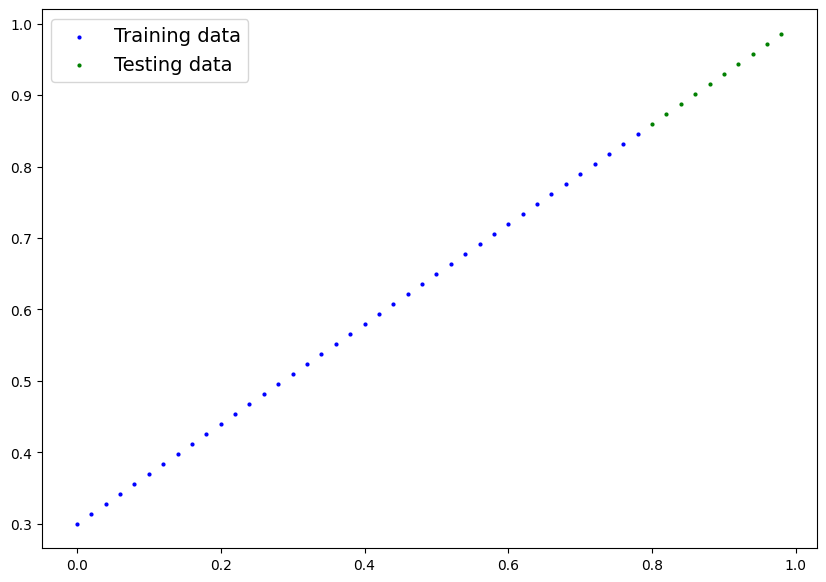

In [43]:
plot_predictions();

## **2. Xây dựng model**

Xây dựng hàm Hồi quy tuyến tính thông qua Pytorch

In [44]:
# Tạo lớp LinearRegression
class LinearRegressionModel(nn.Module): # <- Phần lớn tất cả mọi thứ trong Pytorch đều là nn.Module (giống với nơ ron)
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, # <- Bắt đầu với giá trị weights ngẫu nhiên (giá trị này sẽ thay đổi trong quá trình mô hình học)
                                                dtype=torch.float), # <- PyTorch thực hiện với float
                                   requires_grad=True) # <- Ta có update giá trị này với gradient descent không

        self.bias = nn.Parameter(torch.randn(1, # <- Bắt đầu với giá trị bias ngẫu nhiên (giá trị này sẽ thay đổi trong quá trình mô hình học)
                                            dtype=torch.float), # <- PyTorch thực hiện với float
                                requires_grad=True) # <- Ta có update giá trị này với gradient descent không

    # Hàm xây dựng cho model theo pattern
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" là input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- đây là hàm tuyến tính (y = m*x + b)

### **Xây dựng model cho Pytorch**

Pytorch có khoảng 4 modules thường được sử dụng để tạo ra bất kì mạng nơ ron nào mà ta có thể tưởng tượng được

Các module đó bao gồm:
- `torch.nn:` Xấy dựng blocks cho một đồ thị
- `torch.nn.Parameter:`Lưu trữ tensors có thể sử dụng với `nn.Module`. Nếu `equires_grad=True` cho phép cập nhật thông số dựa theo cách tính gradient descent tự động thể hiện tính chất `autograd` của tensor
- `torch.nn.Module:` Base class cho toàn bộ cấu trúc nơ ron taart carc các block xây dựng trong đáy xem là subclass Nếu xây dựng cấu trúc nơ ron nên có `nn.Module` làm subclass. Được yêu cầu khi viết `forward()`
- `torch.optim:` Lưu trữ các thuật toán tối ưu khác nhau nhằm nói với model rằng các tham số lưu trữ trong `nn.Parameter` nên thay đổi nhưu thé nào để cải thiện gradient descent và từ đó giảm loss
- `def forward():` Tẩt cả `nn.Module` đều yêu cầu phương thức `foward()` định nghĩa cho việc phép tính sẽ diễn ra như thế nào với dữ liệu được truyền vào `nn.Module`

Xem thêm: https://docs.pytorch.org/docs/2.11/nn.html

Nói tóm lại:

- `nn.Module` là block lớn nhất (layers)
- `nn.Parameter` là nơi lưu trữ các tham số truyền vào để tạo nên `nn.Module`
- `foward()` Nói với block lớn nhất là nên tính với input đầu vào như thế nào
- `torch.optim` Lưu trữ phương pháp tối ưu làm sao để tối ưu các tham số trong `nn.Parameter` để diễn giải đầu vào tốt hơn

*Với nn.Module thì foward() phải được định nghĩa*

### **Kiểm tra nội dung có trong model Pytorch**

Điểm kiểm tra các tham số (parameter) có trong model ta sử dụng `.paramnters()`

In [45]:
# Định nghĩa seed cho việc tạo nn.Parameter giữ nguyên giá trị tạo ngẫu nhiên
torch.manual_seed(42)

# Tạo model (subclass của nn.Module chứa nn.Parameter)
model_0 = LinearRegressionModel()

# Kiểm tra nn.Paramter có trong nn.Module
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

Ta cũng có thể biết được giá trị tên gọi của các tham số là gì bằng cách sử dụng `.state_dict()`

In [46]:
# Danh sách tên của các tham số
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### **Dự đoán thông qua `torch.inference_mode()`**

Ta sẽ đưa tập X_test để cho ra dự doán giá trị y rồi sau đó so sánh nói với tập y_test. khi ta làm điều này dữ liệu sẽ vào `forward()` và đưa ra kết quả ta đã định nghĩa

In [47]:
# Dự đoán với model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Một số code sẽ sử dụng torch.no_grad()
# with torch.no_grad():
#    y_preds = model_0(X_test)

# Kiểm tra dự đoán
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


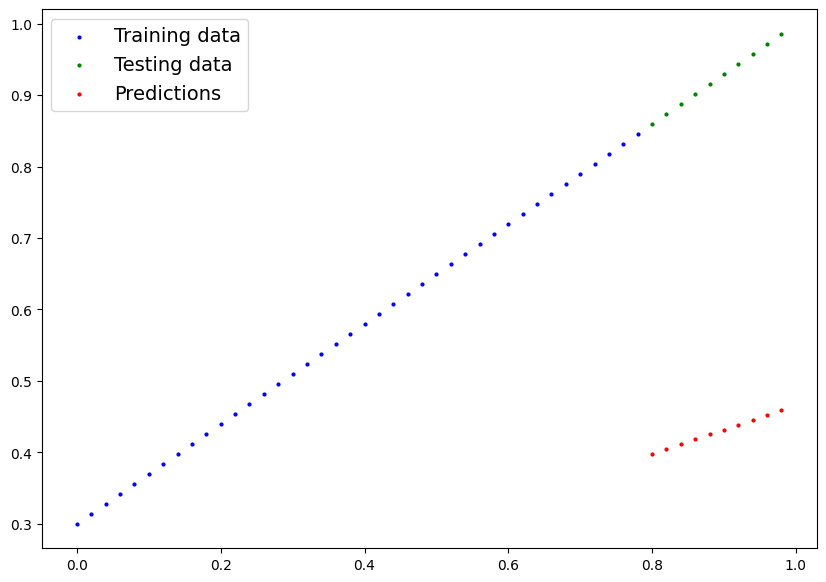

In [48]:
plot_predictions(predictions=y_preds)

In [49]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

Giá trị chêch lệch giữa thực tế và dự đoán là khá lớn điều này cho thấy model chỉ sử dụng các tham số ngẫu nhiên để đưa ra dự đoán chứ chưa thực sự học

## **3. Huấn luyện model**

Bây giờ mô hình của ta thực hiện việc dự đoán dựa trên việc tính toán nhờ các tham số ngẫu nhiên

Ta cập nhật các tham số như `weights` hay `bias` theo các giá trị ngẫu nhiên nhằm mục tiêu có thể diễn giải được các dữ liệu tốt hơn. Ta cũng có thể thay đổi các giá trị như ta đã biết `weight=0.7` và `bias=0.3` là tối ưu bằng cách tìm nghiệm

Tuy nhiên trong một số trường hợp ta không thể biết con số chính xác mà phải nhờ các cỗ máy tự chúng phải tìm ra các con só tối ưu này


### **Tạo hàm loss và optimizer trong Pytorch**

**Loss function:** Biểu diễn rằng liệu dữ liệu mà mô hình dự đoán so với dữ liệu thực tế bao nhiêu (được xây dựng trong torch.nn) các giá trị phổ biến như MAE (cho vấn đè tuyến tính `torch.nn.L1Loss()`) Binary cross entroy cho phân loại nhị phân (`torch.nn.BCELoss()`)

**Optimizer:** Nói mô hình rằng mô hình nên cập nhật tham số nhưu thế nào để dạt loss thấp nhất (được xây duwjgn trong `torch.optim`) các giá trị phổ biến như Stochastic gradient (`torch.optim.SGD()`) và thuật toán Adam (`torch.optim.Adam()`)

Tùy thuộc vào vấn đề ta nên cân nhắc xem nên chọn hàm tối ưu gì và chọn hàm loss gì?. SGD hoặc tối ưu Adam. Hàm loss MAE cho vấn đề tuyền tinh regression (dự đoán số) hoặc phân loại nhị phân cross entropy  

**MAE (Mean Absolute Error):** trong Pytorch `torch.nn.L1Loss` chỉ ra sự khác nhau giữa giá trị dự đoán và giá trị thực tế và sau đó lấy trung bình các giá trị khác nhau đó

**SGD (`torch.optim.SGD(params, lr)`)**
- `params` là mục tiêu tham số model ta muốn tối ưu (có thể là `weight` hoặc `bias` ta chọn ngẫu nhiên)
- `lr:` là tốc độ học mà bạn muốn thuật toán tối ưu cập nhật các tham số, cao hơn có nghĩa là thuật toán tối ưu sẽ thử các cập nhật lớn hơn (điều này đôi khi có thể quá lớn và bộ tối ưu sẽ không hoạt động), thấp hơn có nghĩa là bộ tối ưu sẽ thử các cập nhật nhỏ hơn (điều này đôi khi có thể quá nhỏ và bộ tối ưu sẽ mất quá nhiều thời gian để tìm giá trị lý tưởng). Tốc độ học được coi là một siêu tham số (bởi vì nó được đặt bởi kỹ sư học máy). Các giá trị khởi đầu phổ biến cho tốc độ học là 0.01, 0.001, 0.0001, tuy nhiên, những giá trị này cũng có thể được điều chỉnh theo thời gian (điều này được gọi là lập lịch tốc độ học).

In [50]:
# Tạo loss function
loss_fn = nn.L1Loss() # MAE loss giống với L1Loss

# Tạo thuật toán tối
optimizer = torch.optim.SGD(params=model_0.parameters(), # mục tiêu tham số mà muốn tối ưu
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

### **Tạo vòng lặp tối ưu trong Pytorch**

**Training loop:** Đưa model đi qua các tập training và học mối quan hệ giữa `features` và `labels`

**Testing loop:** Model đi qua tập test và đánh giá patterns mà mô hình học dược từ tập training tốt như ther nào đối với dữ liệu chưa từng thấy trong quá trình học



#### **Training Loop (Vòng lặp huấn luyện)**

- **Forward pass:** Model chạy qua toàn bộ dữ liệu trong tập training một lần, thực hiện tính toán hàm `forward()` - code (`model(x_train)`)
- **Calculate the loss:** Dùng đầu ra của mô hình và so sánh với dữ liệu thực tế và đánh giá xem dữ liệu sai bao nhiều - code (`loss = loss_fn(y_pred, y_train)`)
- **Zero gradients:** Đặt gradient về 0 rổi sau đó tối ưu lại qua mỗi bước train - code (`optimizer.zero_grad()`)
- **Perform backpropagation on the loss:** Tính toán gradient cho hàm loss với từng tham số của mô hình sẽ được cập nhật (`requires_grad=True`). Đây được gọi là lan truyền ngược **(backpropagation)** - code (`loss.backward()`)
- **Update the optimizer (gradient descent):** Cập nhật tham số với (`requires_grad=True`) thông qua gradient của loss để cải thiện chúng - code (`optimizer.step()`)

Một số điểm lưu ý trong training loop:
- Tính toán loss (`loss = ...`) trước khi dùng (`loss.backward()`)
- Zero gradients (`optimizer.zero_grad()`) trước khi tính toán gradients của hàm lost với mỗi giá trị của tham số trong model (`loss.backward()`)
- Bước tối ưu (`optimizer.step()`) phải sau bước lan truyền ngược



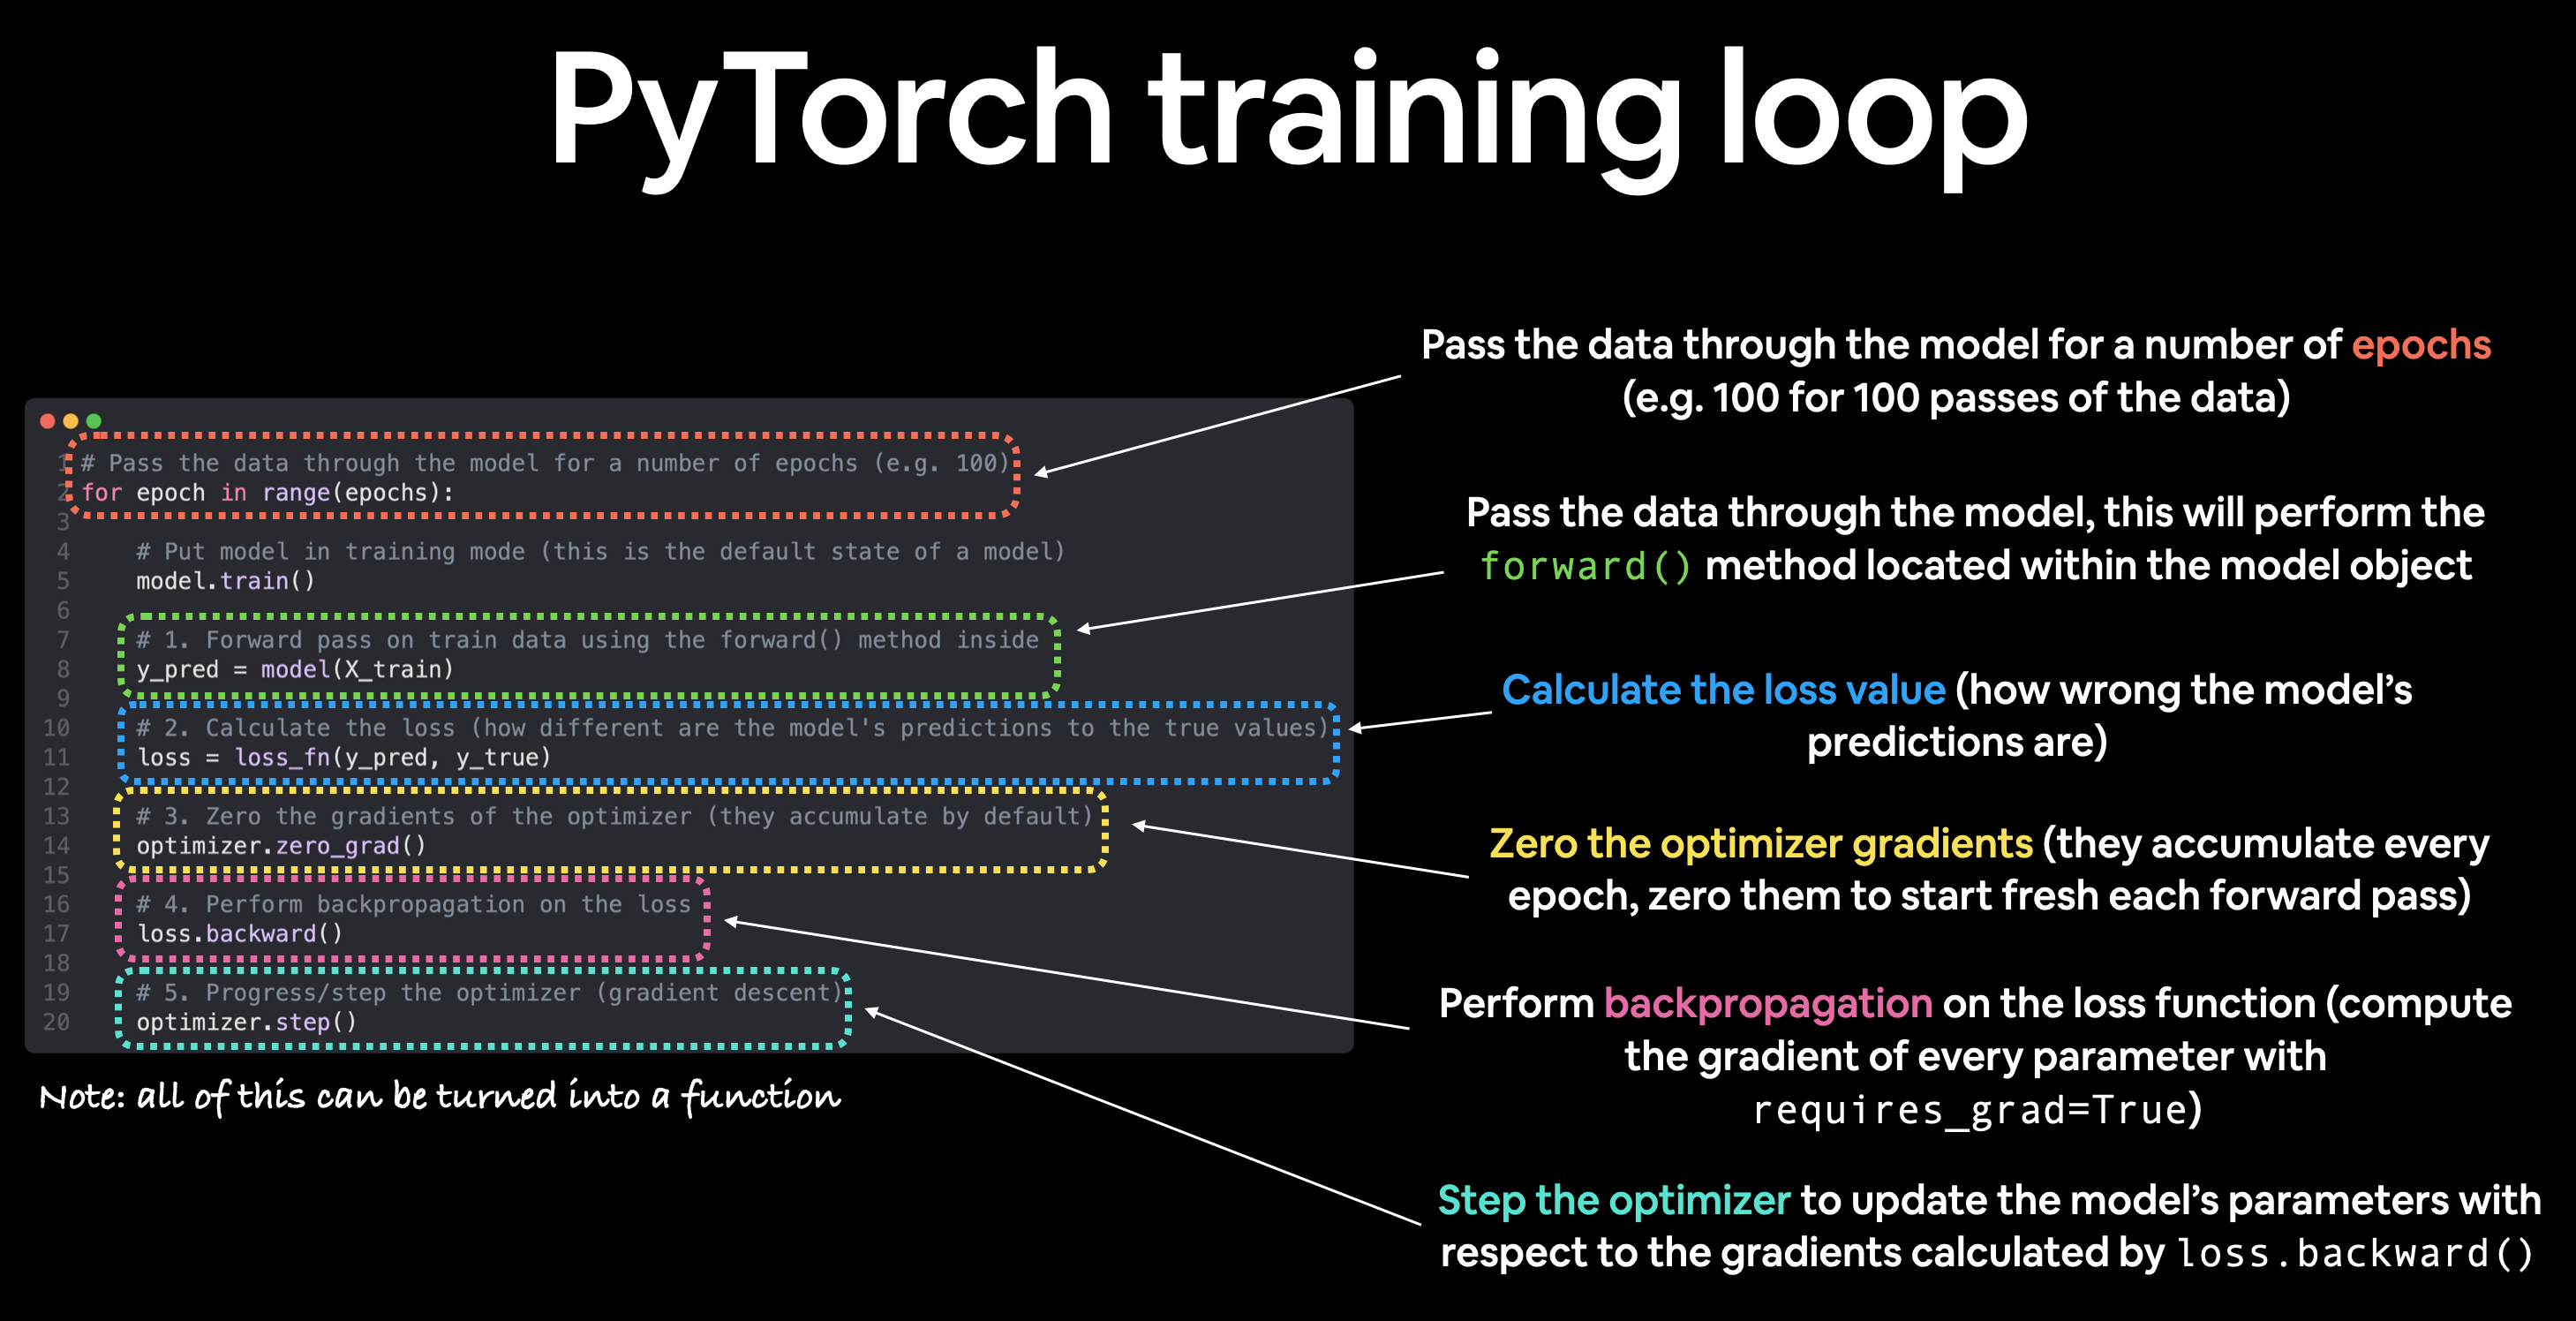

In [60]:
from IPython.display import Image
Image('01-pytorch-training-loop-annotated.png', width=1000)

#### **Testing Loop (Vòng lặp kiểm chứng)**

- **Forward pass:** Model chạy qua toàn bộ dữ liệu trong tập test một lần, thực hiện tính toán các bước nằm trong hàm `forward()` - code (`model(x_test)`)
- **Calculate the loss:** Tính toán mô hình sai bao nhiêu giữa đầu ra cùa mô hình so với dữ liệu thực tế và đánh giá xem chúng bao nhiêu - code (`loss = loss_fn(y_pred, y_test)`)
- **Calulate evaluation metrics (tùy chọn)** Cùng với một số các giá trị loss ta sẽ cần phải tính thêm một số các giá trị đánh giá như Accuracy trong tập test (`tùy theo hàm`)

Lưu ý rằng:
- Không diễn tả bước `loss.backward()` hoặc các bước tối ưu (`optimizer.step()`). Đây là vì không có tham số nào thay đổi trong suốt quá trình testing.
- Cho việc testing chúng ta chỉ tập trung vào đầu ra mong muốn của model

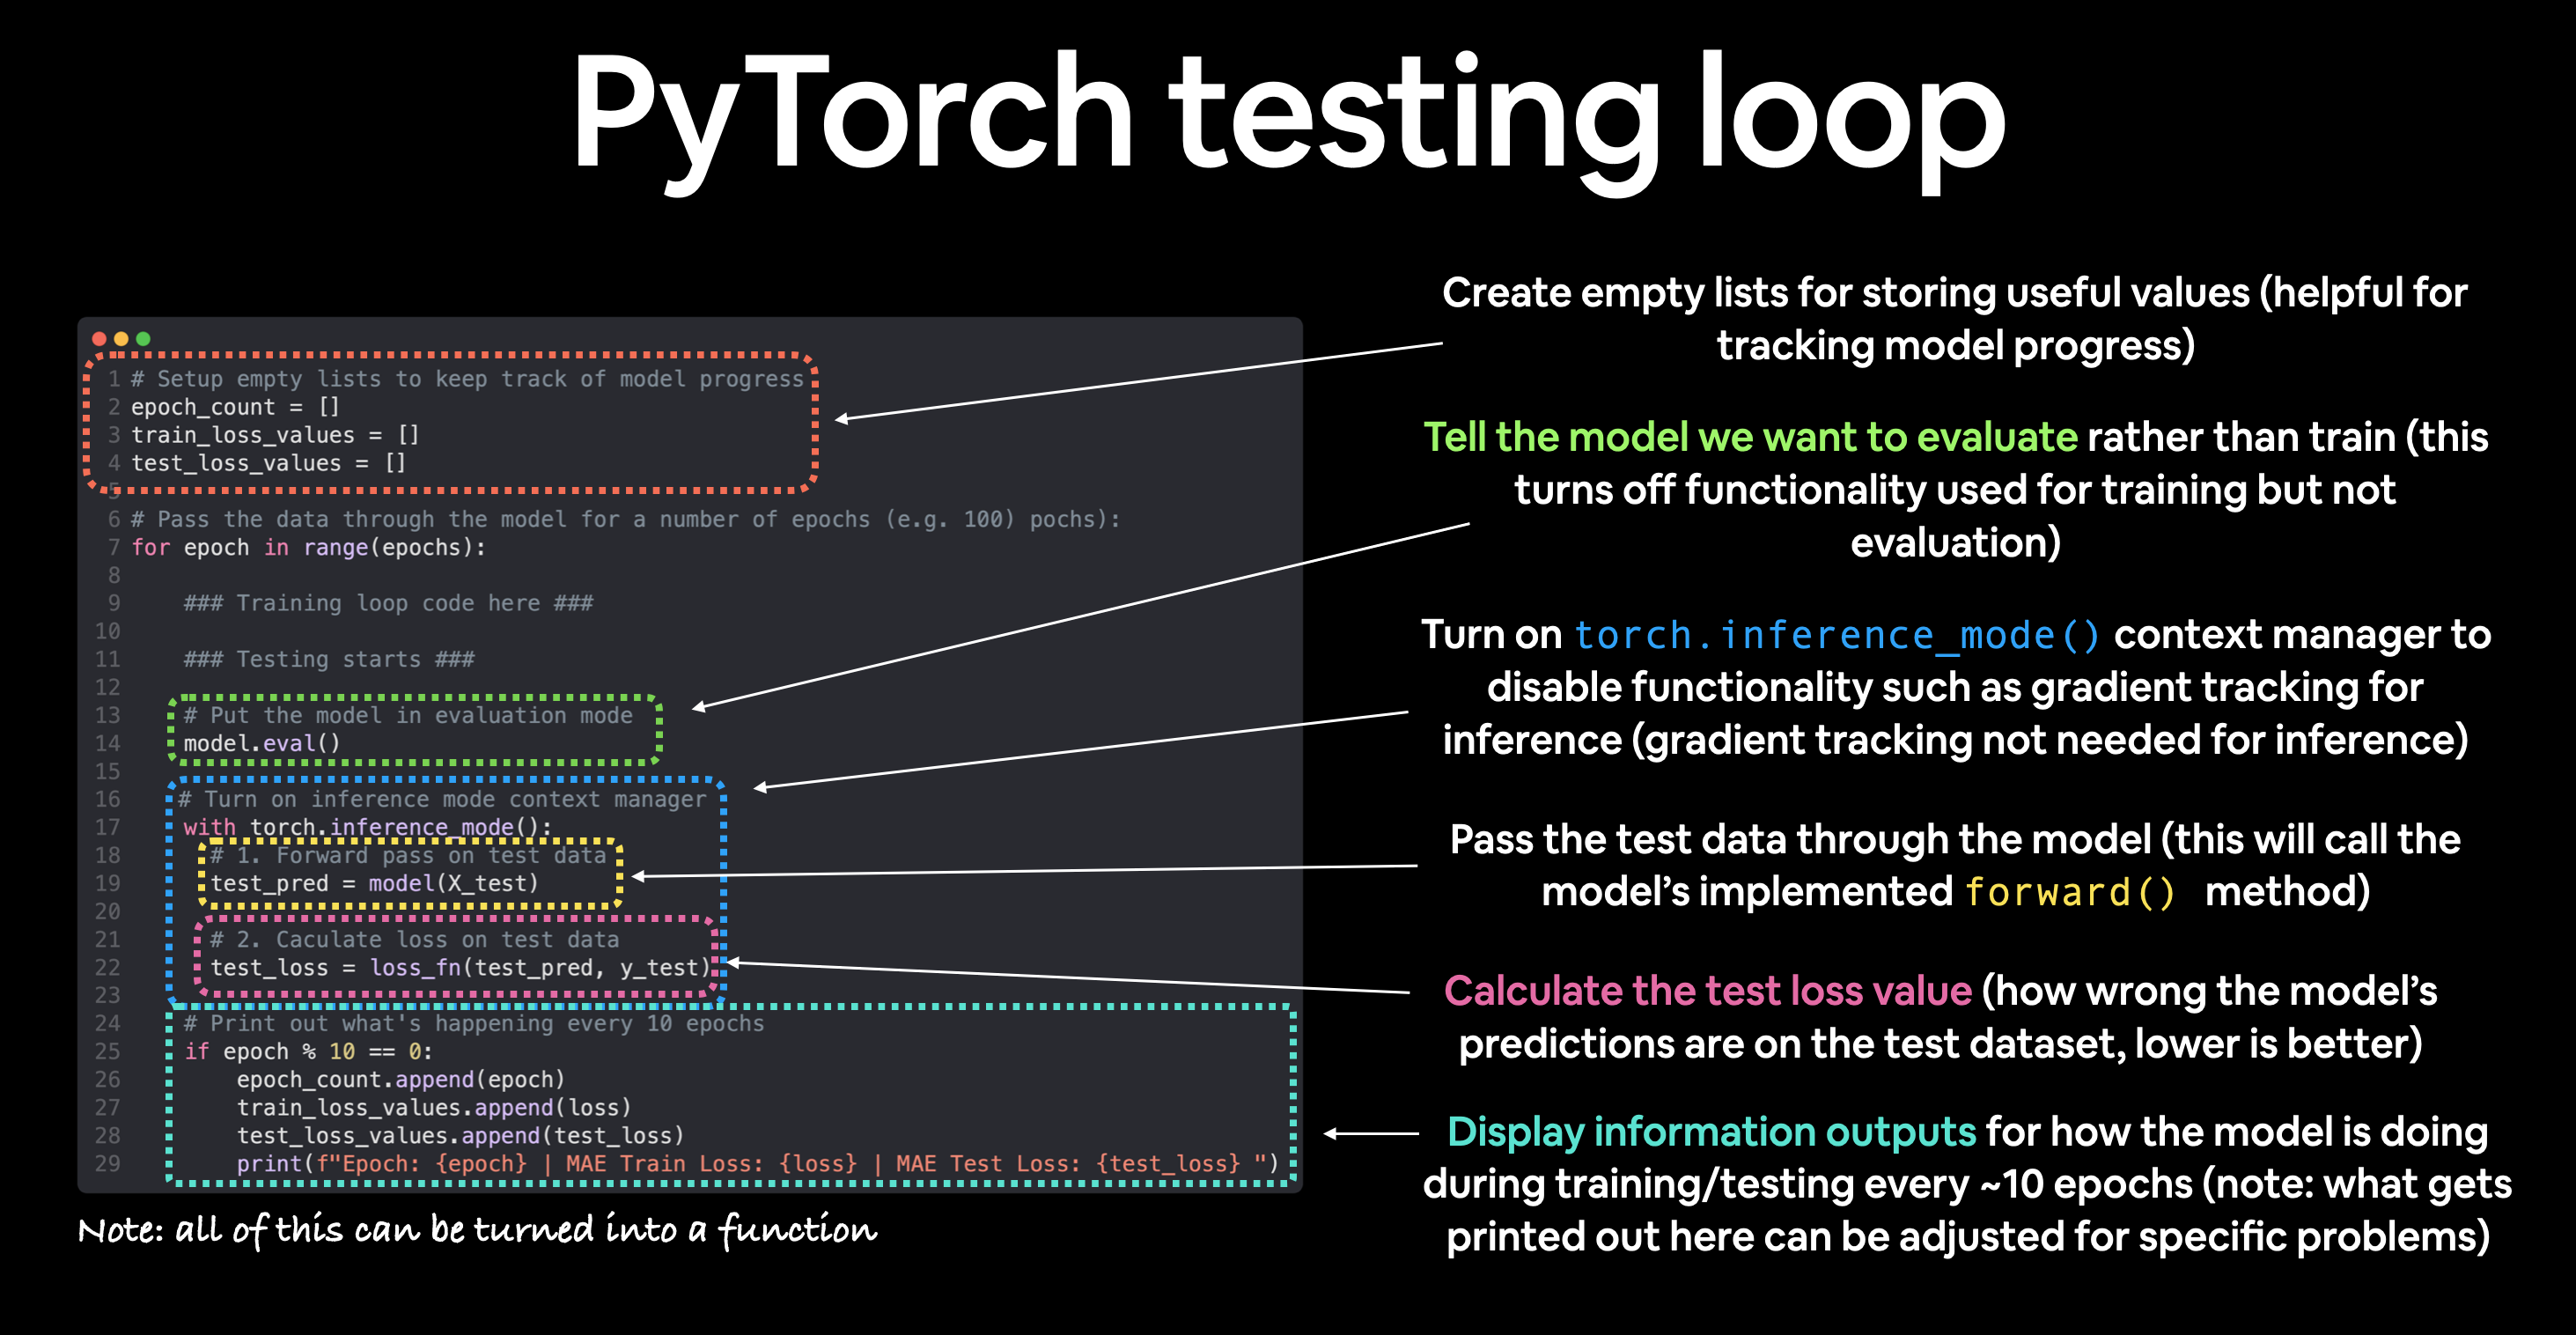

In [59]:
from IPython.display import Image
Image('01-pytorch-testing-loop-annotated.png', width=1000)

In [51]:
# Lấy ví dụ cho việc huấn luyện 100 epochs và đánh giá trên 10 epochs
torch.manual_seed(42)

# Set số lượng epochs (model sẽ học bao nhiêu lần khi qua tập training)
epochs = 100

# Tạo list rỗng loss để lưu trữ giá trị
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Đặt model vào training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 


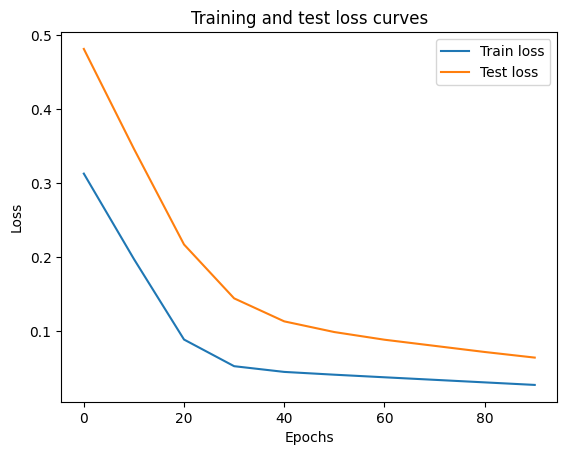

In [52]:
# Plot đường loss
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

**Loss curves:** đường loss càng giảm tức rằng mô hình đang ngày càng học và cập nhật các tham số mà cho dữ liệu đầu ra gần đúng với thực tế  

`.state_dict()` để thấy model tìm ra tham số và set nó giống như thế nào dữ liệu gốc

In [53]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.5784]), 'bias': tensor([0.3513])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


## **4. Đưa ra dự đoán với mô hình train từ Pytorch (inference)**

Sau khi đã thực hiện huấn luyện model, ta sẽ dự đoán với chúng

Có 3 điều cần nhớ khi thực hiện dự đoán (được gọi là inference) với Pytorch
- Đưa model về mode đánh giá (`model.eval()`)
- Thực hiện dự đoán sử dụng mode inference (`with torch.inference_mode()`)
- Tất cả các dự đoán đều phải làm bằng thực hiện trên một đối tượng trong cùng một thiết bị (dữ liệu trong model GPU hoặc dữ liệu chỉ trên CPU)

In [54]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
y_preds

tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

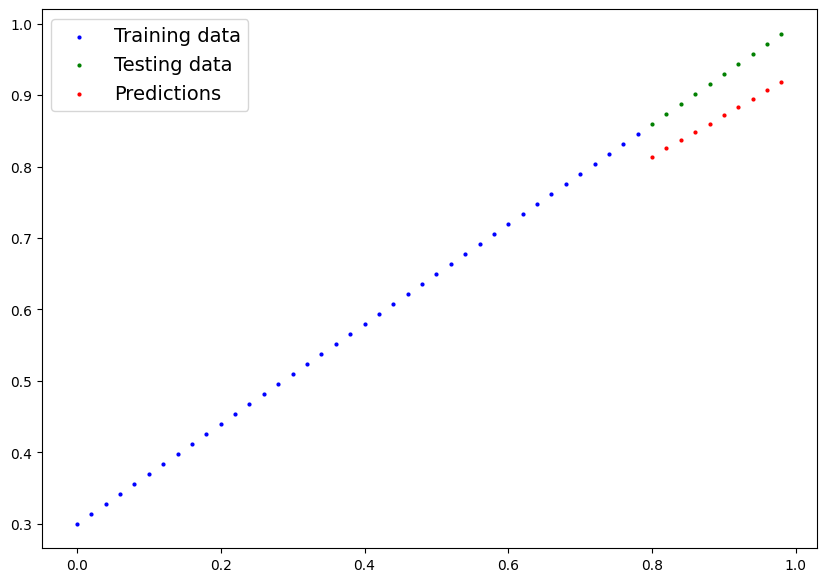

In [55]:
plot_predictions(predictions=y_preds)

## **5. Lưu và nạp model PyTorch**

Để lưu và nạp model trong PyTorch có 3 phương thức ta nên biết ([docs](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html#saving-loading-model-for-inference))

- `torch.save:` Lưu mô hình đã được tuần tự hóa vào đĩa bằng tiện ích pickle của Python. Các mô hình, tensor và nhiều đối tượng Python khác như từ điển có thể được lưu bằng `torch.save.`
- `torch.load:` Sử dụng các tính năng giải pickle của pickle để giải tuần tự hóa và tải các tệp đối tượng Python đã được pickle (như mô hình, tensor hoặc từ điển) vào bộ nhớ.
- `torch.nn.Module.load_state_dict:` Nạp các thư viện trong mô hình sử dụng `state_dict()`

Lưu ý: `pickel` model không an toàn, do đó mà ta nên chỉ load những dữ liệu mà ta tin tưởng. Chỉ lưu các mô hình Pytorch từ nguồn mà ta tin tưởng

## **6. Đặt chúng lại với nhau**
